# Script to view the changes in species concentration and radiative forcing from rocket launches and object re-entries.

In [1]:
# Import modules
import sys, os
#sys.path.append('/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir')
import numpy as np
import netCDF4
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as colors
import cartopy.crs as ccrs
from gamap_colormap import WhGrYlRd
from ipywidgets import interact, IntSlider, SelectionSlider, Dropdown
import math

# Set up arrays
months =['01','02','03','04','05','06','07','08','09','10','11','12']
years = ["2020","2021","2022"]
filepath     = '/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir/'
rocketsSim   = 'Rockets' 
norocketsSim = 'Baseline'
Plower =200
Pupper = 1
species = ["BC","NOx","O3","Al2O3","Cly","CO","DST","H2O"]

### Retrieve concentrations from SpeciesConc over the stratosphere.

In [26]:
mon_mean_nr = np.zeros((len(species),len(months)*len(years),47))
mon_mean_wr = np.zeros((len(species),len(months)*len(years),47))
year_labels = [2020]
trop_height = []
count = 0
for year_count,year in enumerate(years):
    print(year)
    for mth in months:
        year_labels.append(int(mth)/12+year_count+2020)
        if year == "2022" and int(mth) > 11:
            #pass
            continue
        met = xr.open_dataset(f'/home/ucfacb0/Scratch/StateMet/4x5/{year}/GEOSChem.StateMet.{year}{mth}01_0000z.nc4')
        try:
            wr  = xr.open_dataset(f"/home/ucfacb0/Scratch/Old_Rocket_Runs/OutputDir/Rockets/FDH_stratonly/GEOSChem.SpeciesConc.{year}{mth}01_0000z.nc4") 
        except:
            wr  = xr.open_dataset(filepath+rocketsSim+f'/before_atlas_fix/GEOSChem.SpeciesConc.{year}{mth}01_0000z.nc4') 
        nr  = xr.open_dataset(filepath+norocketsSim+f'/GEOSChem.SpeciesConc.{year}{mth}01_0000z.nc4' )

        # Set up the pressure ranges.
        time, lon, lat = nr.variables['time'][:], nr.variables['lon'][:], nr.variables['lat'][:]
        P0, hyai, hybi= nr.variables['P0'], nr.variables['hyai'][:], nr.variables['hybi'][:]
        P0, hyai, hybi = nr.variables['P0'], nr.variables['hyai'][:], nr.variables['hybi'][:]

        Pedge = [ hyai[i] + (hybi[i]*P0.values) for i in np.arange(len(hyai)) ]
        iu = np.argmin(np.abs([ Pedge[i] - Pupper for i in np.arange(len(Pedge)) ] )) # grid index of upper pressure level
        il = np.argmin(np.abs([ Pedge[i] - Plower for i in np.arange(len(Pedge)) ] )) # grid index of lower pressure level
        trop_height.append(met.variables['Met_TropP'][0,:,:].mean(["lat","lon"]).item()) # tropopause height grid level
        if count == 1: 
            trop_height.append(met.variables['Met_TropP'][0,:,:].mean(["lat","lon"]).item()) # tropopause height grid level
            
        #Pedge = Pedge[il:iu]
        
        # Black carbon
        mon_mean_nr[0,count,:] = (nr["SpeciesConcVV_BCPO"].isel(time=0).mean(["lat","lon"]).values + 
                                  nr["SpeciesConcVV_BCPI"].isel(time=0).mean(["lat","lon"]).values) * 1e12
        mon_mean_wr[0,count,:] = (wr["SpeciesConcVV_BCPO"].isel(time=0).mean(["lat","lon"]).values + 
                                  wr["SpeciesConcVV_BCPI"].isel(time=0).mean(["lat","lon"]).values) * 1e12          
        
        # NOx
        mon_mean_nr[1,count,:] = (nr["SpeciesConcVV_NO"].isel(time=0).mean(["lat","lon"]).values + 
                                  nr["SpeciesConcVV_NO2"].isel(time=0).mean(["lat","lon"]).values) * 1e12
        mon_mean_wr[1,count,:] = (wr["SpeciesConcVV_NO"].isel(time=0).mean(["lat","lon"]).values + 
                                  wr["SpeciesConcVV_NO2"].isel(time=0).mean(["lat","lon"]).values) * 1e12  
        
        # Ozone
        mon_mean_nr[2,count,:] =  nr["SpeciesConcVV_O3"].isel(time=0).mean(["lat","lon"]).values * 1e12
        mon_mean_wr[2,count,:] =  wr["SpeciesConcVV_O3"].isel(time=0).mean(["lat","lon"]).values * 1e12 
        
        # Alumina
        mon_mean_wr[3,count,:] =  wr["SpeciesConcVV_AL2O3"].isel(time=0).mean(["lat","lon"]).values * 1e12 
        
        # Chlorine
        mon_mean_nr[4,count,:] = (nr["SpeciesConcVV_Cl"].isel(time=0   ).mean(["lat","lon"]).values + 
                                nr["SpeciesConcVV_Cl2"].isel(time=0  ).mean(["lat","lon"]).values * 2 +
                                nr["SpeciesConcVV_ClNO3"].isel(time=0).mean(["lat","lon"]).values +
                                nr["SpeciesConcVV_Cl2O2"].isel(time=0).mean(["lat","lon"]).values * 2 +
                                nr["SpeciesConcVV_ClO"].isel(time=0  ).mean(["lat","lon"]).values +
                                nr["SpeciesConcVV_ClNO2"].isel(time=0).mean(["lat","lon"]).values +
                                nr["SpeciesConcVV_ClOO"].isel(time=0 ).mean(["lat","lon"]).values +
                                nr["SpeciesConcVV_HCl"].isel(time=0  ).mean(["lat","lon"]).values +
                                nr["SpeciesConcVV_OClO"].isel(time=0 ).mean(["lat","lon"]).values +
                                nr["SpeciesConcVV_BrCl"].isel(time=0 ).mean(["lat","lon"]).values +
                                nr["SpeciesConcVV_HOCl"].isel(time=0 ).mean(["lat","lon"]).values +
                                nr["SpeciesConcVV_ICl"].isel(time=0  ).mean(["lat","lon"]).values) * 1e12
        
        mon_mean_wr[4,count,:] = (wr["SpeciesConcVV_Cl"].isel(time=0).mean(["lat","lon"]).values + 
                                wr["SpeciesConcVV_Cl2"].isel(time=0  ).mean(["lat","lon"]).values * 2 +
                                wr["SpeciesConcVV_ClNO3"].isel(time=0).mean(["lat","lon"]).values +
                                wr["SpeciesConcVV_Cl2O2"].isel(time=0).mean(["lat","lon"]).values * 2 +
                                wr["SpeciesConcVV_ClO"].isel(time=0  ).mean(["lat","lon"]).values +
                                wr["SpeciesConcVV_ClNO2"].isel(time=0).mean(["lat","lon"]).values +
                                wr["SpeciesConcVV_ClOO"].isel(time=0 ).mean(["lat","lon"]).values +
                                wr["SpeciesConcVV_HCl"].isel(time=0  ).mean(["lat","lon"]).values +
                                wr["SpeciesConcVV_OClO"].isel(time=0 ).mean(["lat","lon"]).values +
                                wr["SpeciesConcVV_BrCl"].isel(time=0 ).mean(["lat","lon"]).values +
                                wr["SpeciesConcVV_HOCl"].isel(time=0 ).mean(["lat","lon"]).values +
                                wr["SpeciesConcVV_ICl"].isel(time=0  ).mean(["lat","lon"]).values) * 1e12
        
        # Carbon Monoxide
        mon_mean_nr[5,count,:] =  nr["SpeciesConcVV_CO"].isel(time=0).mean(["lat","lon"]).values * 1e12
        mon_mean_wr[5,count,:] =  wr["SpeciesConcVV_CO"].isel(time=0).mean(["lat","lon"]).values * 1e12
        
        # Dust
        mon_mean_nr[6,count,:] =  (nr["SpeciesConcVV_DST1"].isel(time=0).mean(["lat","lon"]).values +
                                 nr["SpeciesConcVV_DST2"].isel(time=0).mean(["lat","lon"]).values +
                                 nr["SpeciesConcVV_DST3"].isel(time=0).mean(["lat","lon"]).values +
                                 nr["SpeciesConcVV_DST4"].isel(time=0).mean(["lat","lon"]).values) * 1e12
        mon_mean_wr[6,count,:] =  (wr["SpeciesConcVV_DST1"].isel(time=0).mean(["lat","lon"]).values +
                                 wr["SpeciesConcVV_DST2"].isel(time=0).mean(["lat","lon"]).values +
                                 wr["SpeciesConcVV_DST3"].isel(time=0).mean(["lat","lon"]).values +
                                 wr["SpeciesConcVV_DST4"].isel(time=0).mean(["lat","lon"]).values) * 1e12
        
        # H2O
        mon_mean_nr[7,count,:] =  nr["SpeciesConcVV_H2O"].isel(time=0).mean(["lat","lon"]).values * 1e12
        mon_mean_wr[7,count,:] =  wr["SpeciesConcVV_H2O"].isel(time=0).mean(["lat","lon"]).values * 1e12
                    
        # Keep the counter going and build the x axis label array.
        count += 1

print(year_labels)
trop_height.append(trop_height[-1])


2020
2021
2022
[2020, 2020.0833333333333, 2020.1666666666667, 2020.25, 2020.3333333333333, 2020.4166666666667, 2020.5, 2020.5833333333333, 2020.6666666666667, 2020.75, 2020.8333333333333, 2020.9166666666667, 2021.0, 2021.0833333333333, 2021.1666666666667, 2021.25, 2021.3333333333333, 2021.4166666666667, 2021.5, 2021.5833333333333, 2021.6666666666667, 2021.75, 2021.8333333333333, 2021.9166666666667, 2022.0, 2022.0833333333333, 2022.1666666666667, 2022.25, 2022.3333333333333, 2022.4166666666667, 2022.5, 2022.5833333333333, 2022.6666666666667, 2022.75, 2022.8333333333333, 2022.9166666666667, 2023.0]


In [27]:
wr.close()
nr.close()
met.close()

### Output the SpeciesConc Plots

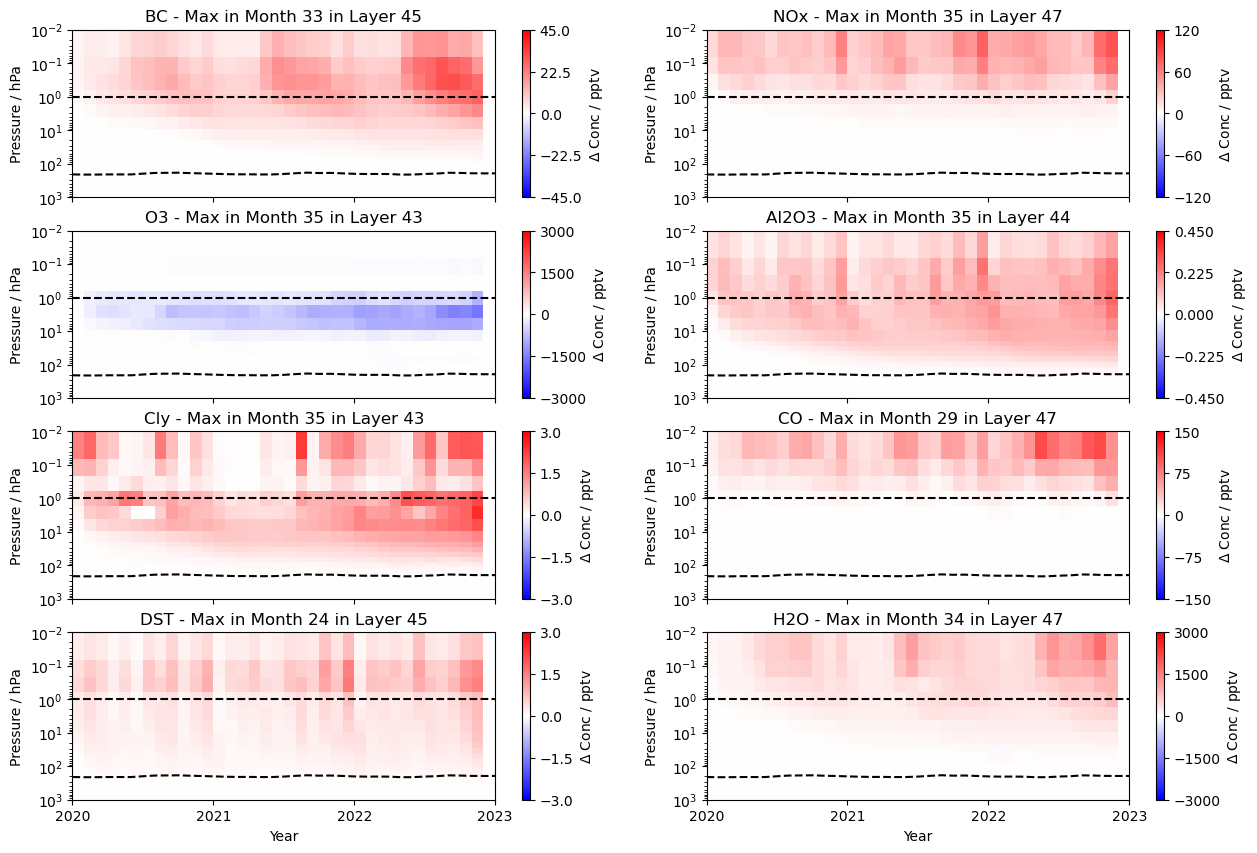

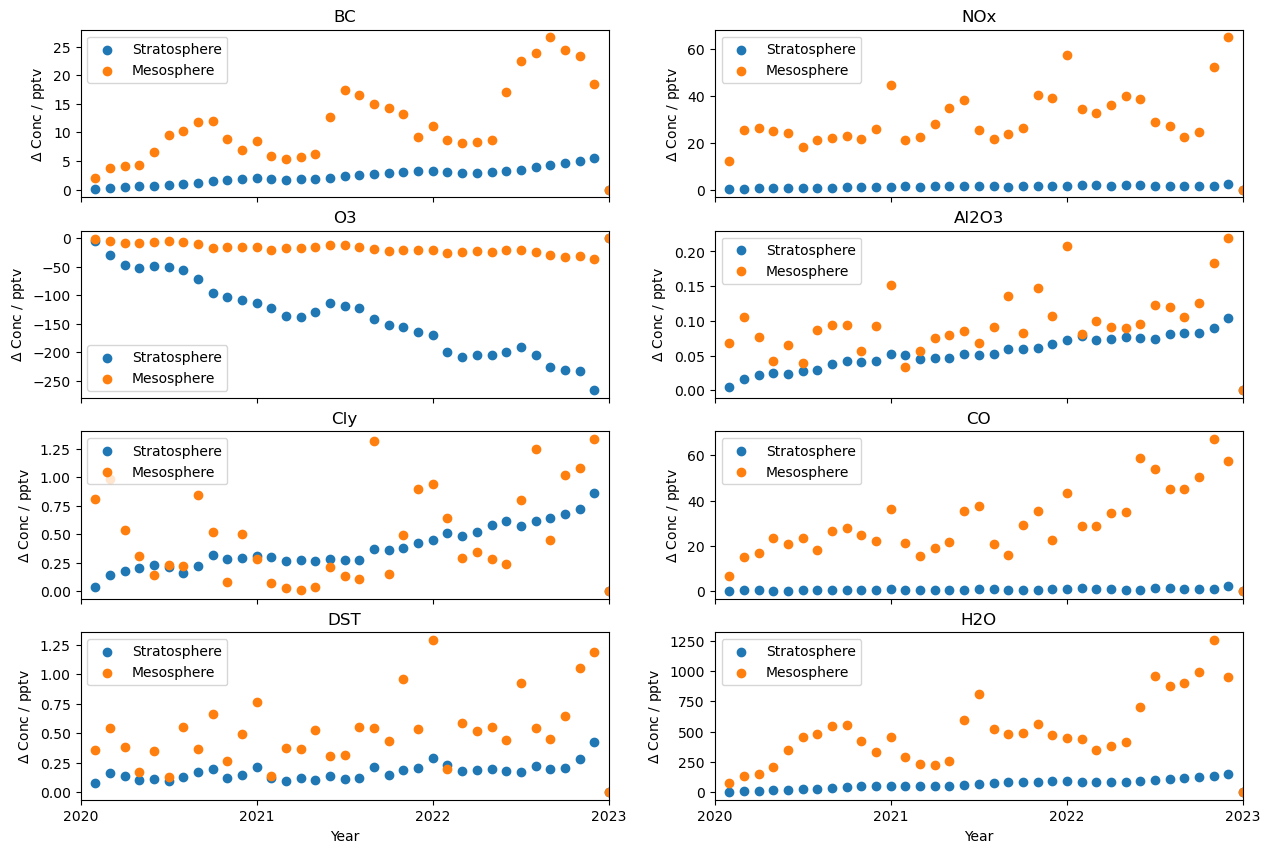

In [31]:
extent = [12000,4,0.05,0,0.2,1,2e17]
fig, ax = plt.subplots(4,2,figsize=(15,10))
fig1, ax1 = plt.subplots(4,2,figsize=(15,10))
rows = [0,0,1,1,2,2,3,3]
cols = [0,1,0,1,0,1,0,1]
for spec_count in range(len(species)):
    #if spec_count == 3:
        #continue
    mon_mean = mon_mean_wr[spec_count,:,:]-mon_mean_nr[spec_count,:,:]
    
    mon_mean_plot = mon_mean
    lbl = "$\Delta$ Conc / pptv"
    #mon_mean_plot = mon_mean / mon_mean_nr[spec_count,:,:] * 100
    #lbl = "$\Delta$ Conc / %"
    
    
    order = 10**math.floor(math.log(np.nanmax(np.abs(mon_mean_plot)), 10))
    extent = ((np.nanmax(np.abs(mon_mean_plot)) / order)).round(0)*1.5 * order
    max_ind = np.unravel_index(np.nanargmax(np.abs(mon_mean_plot)),np.shape(mon_mean_plot))
    
    
    plot_row = rows[spec_count]
    plot_col = cols[spec_count]
    cf = ax[plot_row,plot_col].pcolormesh(year_labels,Pedge,mon_mean_plot.T, cmap ='bwr', vmin=-extent, vmax=extent,shading='flat')
    ax[plot_row,plot_col].plot(year_labels,np.full((len(year_labels)),1),'--',color="black")
    ax[plot_row,plot_col].plot(year_labels,trop_height,'--',color="black")
    ax[plot_row,plot_col].set_xticks(np.linspace(2020,2023,4))
    ax[plot_row,plot_col].set_xlim(2020,2023)
    ax[plot_row,plot_col].set_yscale('log')
    ax[plot_row,plot_col].set_ylim(0.01,1000)
    ax[plot_row,plot_col].invert_yaxis()
    ax[plot_row,plot_col].set_xlabel("Year")
    if spec_count not in [6,7]:
        ax[plot_row,plot_col].set_xlabel("")  
        ax[plot_row,plot_col].set_xticklabels("")
    
    ax[plot_row,plot_col].set_ylabel("Pressure / hPa")
    ax[plot_row,plot_col].set_title(f"{species[spec_count]} - Max in Month {max_ind[0]+1} in Layer {max_ind[1]+1}")
    ticks=[-extent, -extent/2, 0, extent/2, extent]
    cbar = fig.colorbar(cf, ax=ax[plot_row,plot_col], orientation='vertical',
                        ticks=ticks,label=lbl)
    #cbar.ax[plot_row,plot_col].set_yticklabels(ticks);

    ax1[plot_row,plot_col].scatter(year_labels[1:],np.mean(mon_mean_plot[:,il:iu],axis=1),label="Stratosphere")
    ax1[plot_row,plot_col].scatter(year_labels[1:],np.mean(mon_mean_plot[:,iu:],axis=1),label="Mesosphere")
    ax1[plot_row,plot_col].set_xticks(np.linspace(2020,2023,4))
    ax1[plot_row,plot_col].set_xlim(2020,2023)
    ax1[plot_row,plot_col].set_xlabel("Year")
    ax1[plot_row,plot_col].set_title(f"{species[spec_count]}")
    ax1[plot_row,plot_col].set_ylabel(lbl)
    ax1[plot_row,plot_col].legend()
    if spec_count not in [6,7]:
        ax1[plot_row,plot_col].set_xlabel("")  
        ax1[plot_row,plot_col].set_xticklabels("")
    
#mon_mean_diff_al = mon_mean_wr[3,:]-mon_mean_nr[3,:]
#mon_mean_diff_du = mon_mean_wr[6,:]-mon_mean_nr[6,:]
#fig, ax = plt.subplots(figsize=(7,2))
#ax.scatter(year_labels,np.insert(mon_mean_diff_du/mon_mean_diff_al,0,0))
#ax.set_xlabel("Year")
#ax.set_ylabel("DST1-4/Al2O3 ratio / unitless")
#ax.set_xticks(np.linspace(2020,2030,11))
#ax.set_title(f"Ratio between DST1-4 and Al2O3 concentrations")

In [29]:
wr.close()
nr.close()
met.close()